<a href="https://colab.research.google.com/github/hasinikondle/DataScience_Task/blob/main/Zomato_Restaurant_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zomato Bangalore Data Analysis
Objective:
To perform Exploratory Data Analysis (EDA) on the Zomato Bangalore dataset and generate
meaningful business insights using Python **bold text**.

**Task : 1)Data Understanding & Cleaning**



In [ ]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# loading the zomato excel file
df = pd.read_excel("zomato_rest_data.xlsx")

In [ ]:
# displaying first 5 rows
df.head()

,Unnamed: 0,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
# display shape of dataset
df.shape

(51717, 18)

In [ ]:
# list column names
df.columns

Index(['Unnamed: 0', 'url', 'address', 'name', 'online_order', 'book_table',
       'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked',
       'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   51717 non-null  int64 
 1   url                          51717 non-null  object
 2   address                      51717 non-null  object
 3   name                         51717 non-null  object
 4   online_order                 51717 non-null  object
 5   book_table                   51717 non-null  object
 6   rate                         43942 non-null  object
 7   votes                        51717 non-null  int64 
 8   phone                        50509 non-null  object
 9   location                     51696 non-null  object
 10  rest_type                    51490 non-null  object
 11  dish_liked                   23639 non-null  object
 12  cuisines                     51672 non-null  object
 13  approx_cost(for two people)  51

In [ ]:
# Identify missing values
df.isnull().sum()

,0
Unnamed: 0,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21


Since we have more null values we cannot use dropna().Because a huge amount of data will be lost

2)**Data Cleaning**

**Removing unwanted columns**

In [ ]:

# Unnamed: 0","url","phone","address","location","rest_type","reviews_list,menu_items
df = df.drop(["Unnamed: 0","url","phone","address","location","rest_type","reviews_list","menu_item"],axis=1)

In [ ]:
# removing duplicate rows
df.drop_duplicates(inplace=True)

In [ ]:
# checking shape to know dupicates removed
df.shape

(51577, 10)

**Handling every column**

In [ ]:
# checking data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51577 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         51577 non-null  object
 1   online_order                 51577 non-null  object
 2   book_table                   51577 non-null  object
 3   rate                         43853 non-null  object
 4   votes                        51577 non-null  int64 
 5   dish_liked                   23595 non-null  object
 6   cuisines                     51532 non-null  object
 7   approx_cost(for two people)  51233 non-null  object
 8   listed_in(type)              51577 non-null  object
 9   listed_in(city)              51577 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.3+ MB


In [ ]:
# handling name column
df["name"].unique()
# we dont have any issues with name column , but we have to rename column to speicify it is restauarant name
# renaming name column
df.rename(columns={"name":"restaurant_name"},inplace = True)



In [ ]:
# handling online_order column
df["online_order"].unique()
# no issues

array(['Yes', 'No'], dtype=object)

In [ ]:
# handling book_table column
df["book_table"].unique()
# no issues

array(['Yes', 'No'], dtype=object)

In [ ]:
# handling rate column
df["rate"].unique()
# renaming rate to rating
df.rename(columns={"rate":"rating"},inplace = True)
# removing unwanted data in rating
df["rating"] = df["rating"].str.strip(" /5")
# handling "NEW" and "-" in rating column
# replacing new and - with null values
df["rating"] = df["rating"].replace("NEW",np.nan)
df["rating"] = df["rating"].replace("-",np.nan)
# converting rating object datatype to float datatype
df["rating"] = df["rating"].astype(float)
# filling null values in rating column
# calculate mean of rating and fill at places of null values
mean = round(df["rating"].mean()) #4
mean
df["rating"] = df["rating"].fillna(4)
df["rating"].unique()
# now rating column is cleaned

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 2.6, 3.4, 2. , 2.7, 4.7, 2.4, 2.2, 2.3, 4.8, 4.9,
       2.1, 1.8])

In [ ]:
# handling votes column
df["votes"].unique()
# no issues

array([ 775,  787,  918, ..., 4957, 2382,  843])

In [ ]:
# handling dish_liked column
# calculate mode
mode =df["dish_liked"].mode() #Biryani
mode
# fill null values with mode
df["dish_liked"] = df["dish_liked"].fillna("Biryani")
# check null values removed or not
df["dish_liked"].unique()


array(['Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup',
       'Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani',
       'Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza',
       ...,
       'Noodles, Chicken Noodle, Momos, American Chopsuey, Salad, Manchow Soup, Manchurian',
       'Chicken Quesadilla, Naan, Breakfast Buffet, Cheesecake, Cocktails, Lunch Buffet, Biryani',
       'Biryani, Andhra Meal'], dtype=object)

In [ ]:
# handling cuisines column
# handlinh null values in column
# caculate mode
mode = df["cuisines"].mode()
mode
# fill null value with mode
df["cuisines"] = df["cuisines"].fillna("North Indian")



In [ ]:
# handling approx_cost column
# renaming approx_cost to cost_per_two
df.rename(columns={"approx_cost(for two people)":"cost_per_two"},inplace = True)
# removing unwanted commas
df["cost_per_two"] = df["cost_per_two"].str.replace(",","")
# converting datatype
df["cost_per_two"] = df["cost_per_two"].astype(float)

# handling null values
mean = round(df["cost_per_two"].mean())
df["cost_per_two"] = df["cost_per_two"].fillna(mean)
df["cost_per_two"].unique()


array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700.,  555., 1400.,  180., 1350.,
       2200., 2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800.,
       3400.,   40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,
        469.,   70., 3200.,   60.,  560.,  240.,  360., 6000., 1050.,
       2300., 4100., 5000., 3700., 1650., 2700., 4500.,  140.])

In [ ]:
# handling listed_in(type) column
# renaming column to rest_type
df.rename(columns={"listed_in(type)":"rest_type"},inplace=True)
df["rest_type"].unique()
# no issues in rest_type column

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

In [ ]:
# handling listed_in(city) column
# renaming the column to location
df.rename(columns={"listed_in(city)":"location"},inplace=True)
df["location"].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

In [ ]:
df

,restaurant_name,online_order,book_table,rating,votes,dish_liked,cuisines,cost_per_two,rest_type,location
0,Jalsa,Yes,Yes,4.1,775,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,"Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Masala Dosa,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Biryani,Continental,1500.0,Pubs and bars,Whitefield
51713,Vinod Bar And Restaurant,No,No,4.0,0,Biryani,Finger Food,600.0,Pubs and bars,Whitefield
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,4.0,0,Biryani,Finger Food,2000.0,Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"Cocktails, Pizza, Buttermilk",Finger Food,2500.0,Pubs and bars,Whitefield


In [ ]:
df.isnull().sum()

,0
restaurant_name,0
online_order,0
book_table,0
rating,0
votes,0
dish_liked,0
cuisines,0
cost_per_two,0
rest_type,0
location,0


**Task - 2: : Univariate Analysis**

1. Top 5 locations with highest number of restaurants

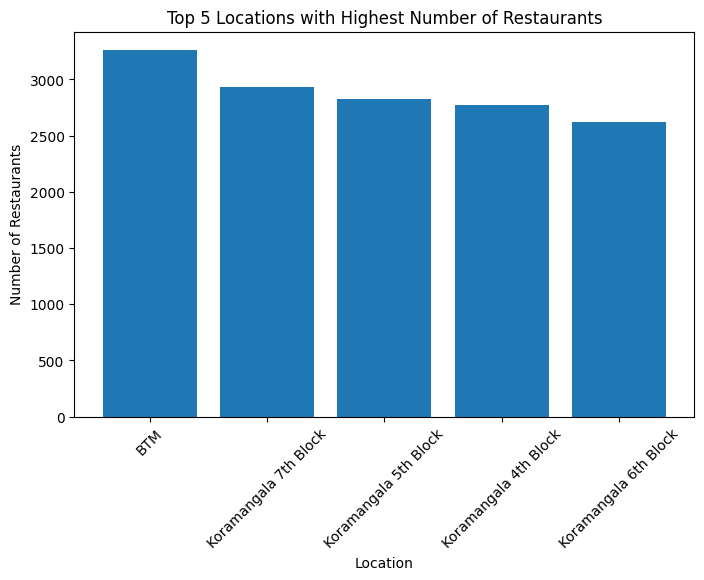

In [ ]:
#1) Top 5 locations with highest number of restaurants
top_locations = df['location'].value_counts().head(5)

plt.figure(figsize=(8,5))
plt.bar(top_locations.index, top_locations.values)
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")
plt.title("Top 5 Locations with Highest Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

The top 5 locations have the highest concentration of restaurants, indicating these areas are major food hubs.

 These locations likely have higher population density.

 This suggests strong customer demand and business competition in these areas

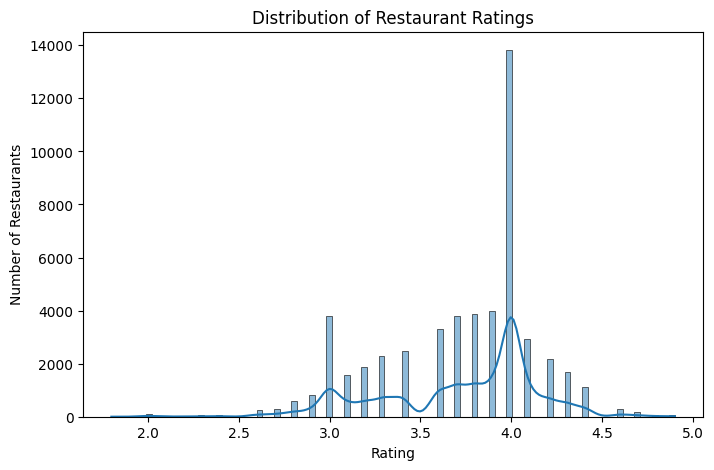

In [ ]:
# 2)Distribution of restaurant ratings
plt.figure(figsize=(8,5))
sns.histplot(df['rating'],kde=True)
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurant Ratings")
plt.show()

Most restaurants have ratings between 3.5 and 4.2, indicating generally good customer satisfaction.

Highest rating is 4 for most of the restaurants.

 Very few restaurants have extremely low or near-perfect ratings.

 Overall, the distribution suggests that the majority of restaurants maintain decent quality standards.

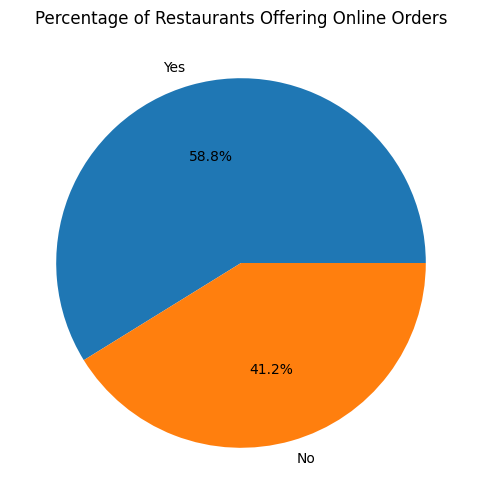

In [ ]:
# 3)Percentage of restaurants offering online orders

online_counts = df['online_order'].value_counts()
percentages = (online_counts / online_counts.sum()) * 100

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(percentages, labels=percentages.index, autopct='%1.1f%%')
plt.title("Percentage of Restaurants Offering Online Orders")
plt.show()

Around 58.8% of restaurants offer online ordering, which means more than half have adapted to digital platforms.

This shows that online food delivery has become a common and important service.

About 41% still do not offer it, indicating room for further digital adoption.

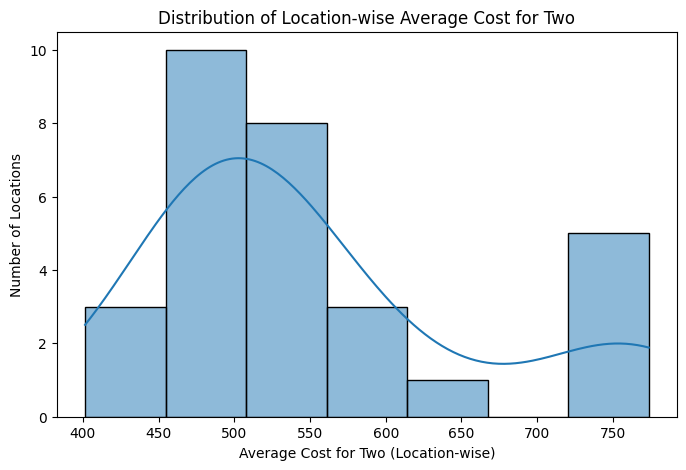

In [ ]:
# 4)Distribution of average cost for two
# Step 1: Calculate average cost_per_two for each location
location_avg_cost = df.groupby('location')['cost_per_two'].mean()

# Step 2: Plot histogram of location-wise average cost
plt.figure(figsize=(8,5))
sns.histplot(location_avg_cost, kde=True)
plt.xlabel("Average Cost for Two (Location-wise)")
plt.ylabel("Number of Locations")
plt.title("Distribution of Location-wise Average Cost for Two")
plt.show()

Most locations have an average cost for two between ₹450 and ₹550, indicating that mid-range pricing dominates across areas.

Very few locations have higher average costs (above ₹700), showing that premium pricing is limited to select areas.

The market is more in the mid-range segment.



#Task : 3 Bivariate Analysis

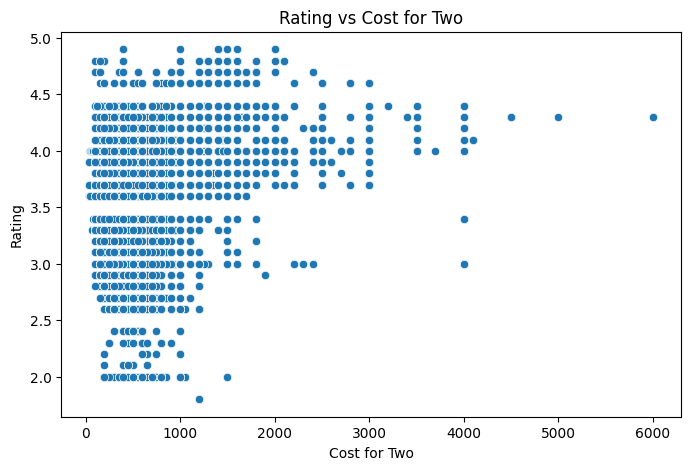

In [ ]:
# 1)Rating vs Cost

plt.figure(figsize=(8,5))
sns.scatterplot(x='cost_per_two', y='rating', data=df)
plt.xlabel("Cost for Two")
plt.ylabel("Rating")
plt.title("Rating vs Cost for Two")
plt.show()

Most restaurants in the mid-range cost category (₹0–₹1000) have ratings between 3.5 and 4.2, showing strong customer satisfaction in this price segment.

This suggests that customers prefer restaurants that offer good quality at reasonable prices.

 Extremely high cost does not necessarily result in higher ratings, indicating that value for money plays an important role in customer reviews.

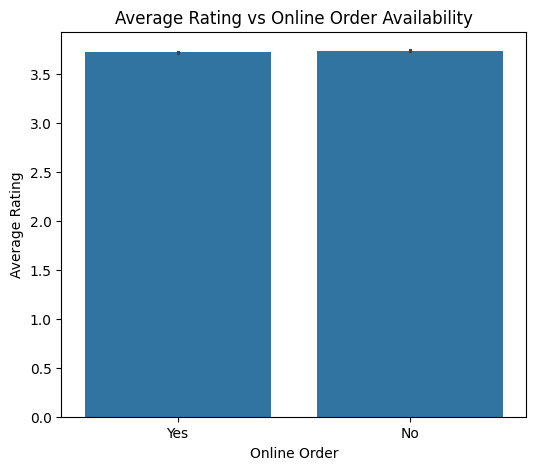

In [ ]:
# 2)Rating vs Online Order
plt.figure(figsize=(6,5))
sns.barplot(x='online_order', y='rating', data=df)
plt.xlabel("Online Order")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Online Order Availability")
plt.show()

The average ratings for restaurants that offer online ordering and those that do not are almost the same.

This indicates that online order availability does not significantly impact customer ratings.

So, customer satisfaction seems to depend more on food quality and service rather than whether the restaurant provides online ordering.

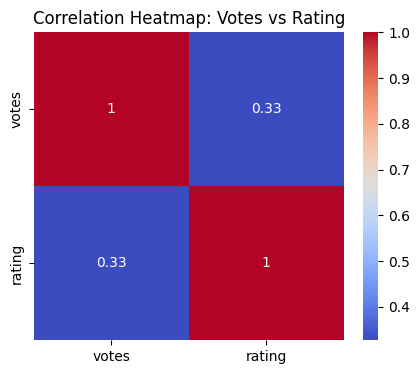

In [ ]:
# 3)Votes vs Rating

# Create a correlation matrix for numeric columns
corr_matrix = df[['votes', 'rating']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap: Votes vs Rating")
plt.show()

There is no correlation between rating and votes(near to 0).so the votes does not depends on rating.

# Task 4 :Business Insights & Recommendations

In [ ]:
# 1. Does higher cost lead to higher ratings?
# yes the higher cost leading to higher ratings.

In [ ]:
# 2. Does offering online order impact ratings?
# There is no major difference in ratings between restaurants that offer online ordering and those that do not.
# This suggests that online availability alone does not significantly influence customer ratings.
# customer liking equally.


In [ ]:
# 3. Which location appears highly competitive?
# The location with the highest number of restaurants is BTM, appears to be the most competitive.


In [ ]:
# 4. Where would you recommend opening a new restaurant?
# I would recommend opening a new restaurant in a growing or moderately populated location rather than the most saturated one(New BEL Road,Banashankari,Rajajinagar).



In [ ]:
# save cleaned data
df.to_csv("cleaned_data.csv")